# Project | Ensemble Techniques

# Parkinson’s Disease diagnosis

In [1]:
#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn import metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

In [2]:
colnames = ['name', 'MDVP_F_avg', 'MDVP_F_max', 'MDVP_F_min', 'MDVP_Jitter_pct',
              'MDVP_Jitter_abs', 'MDVP_RAP', 'MDVP_PPQ', 'Jitter_DDP',
              'MDVP_Shimmer', 'MDVP_Shimme_db', 'Shimmer_APQ3', 'Shimmer_APQ5',
              'MDVP_APQ', 'Shimmer_DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
              'spread1', 'spread2', 'D2', 'PPE']

In [3]:
# import data
park_df= pd.read_csv("parkinsons.data")

In [4]:
park_df.head(1).T

,0
name,phon_R01_S01_1
MDVP:Fo(Hz),119.992
MDVP:Fhi(Hz),157.302
MDVP:Flo(Hz),74.997
MDVP:Jitter(%),0.00784
MDVP:Jitter(Abs),7e-05
MDVP:RAP,0.0037
MDVP:PPQ,0.00554
Jitter:DDP,0.01109
MDVP:Shimmer,0.04374


In [5]:
#park_df=park_df.drop(0, axis=0)

park_df.columns=colnames

In [6]:
park_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP_F_avg,195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP_F_max,195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP_F_min,195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP_Jitter_pct,195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP_Jitter_abs,195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP_RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP_PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter_DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP_Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP_Shimme_db,195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [7]:
park_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name               195 non-null object
MDVP_F_avg         195 non-null float64
MDVP_F_max         195 non-null float64
MDVP_F_min         195 non-null float64
MDVP_Jitter_pct    195 non-null float64
MDVP_Jitter_abs    195 non-null float64
MDVP_RAP           195 non-null float64
MDVP_PPQ           195 non-null float64
Jitter_DDP         195 non-null float64
MDVP_Shimmer       195 non-null float64
MDVP_Shimme_db     195 non-null float64
Shimmer_APQ3       195 non-null float64
Shimmer_APQ5       195 non-null float64
MDVP_APQ           195 non-null float64
Shimmer_DDA        195 non-null float64
NHR                195 non-null float64
HNR                195 non-null float64
status             195 non-null int64
RPDE               195 non-null float64
DFA                195 non-null float64
spread1            195 non-null float64
spread2            195 non-null float64
D2                

In [8]:
park_df.columns

Index(['name', 'MDVP_F_avg', 'MDVP_F_max', 'MDVP_F_min', 'MDVP_Jitter_pct',
       'MDVP_Jitter_abs', 'MDVP_RAP', 'MDVP_PPQ', 'Jitter_DDP', 'MDVP_Shimmer',
       'MDVP_Shimme_db', 'Shimmer_APQ3', 'Shimmer_APQ5', 'MDVP_APQ',
       'Shimmer_DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1',
       'spread2', 'D2', 'PPE'],
      dtype='object')

In [9]:
park_df=park_df.set_index('name')

In [10]:
park_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, phon_R01_S01_1 to phon_R01_S50_6
Data columns (total 23 columns):
MDVP_F_avg         195 non-null float64
MDVP_F_max         195 non-null float64
MDVP_F_min         195 non-null float64
MDVP_Jitter_pct    195 non-null float64
MDVP_Jitter_abs    195 non-null float64
MDVP_RAP           195 non-null float64
MDVP_PPQ           195 non-null float64
Jitter_DDP         195 non-null float64
MDVP_Shimmer       195 non-null float64
MDVP_Shimme_db     195 non-null float64
Shimmer_APQ3       195 non-null float64
Shimmer_APQ5       195 non-null float64
MDVP_APQ           195 non-null float64
Shimmer_DDA        195 non-null float64
NHR                195 non-null float64
HNR                195 non-null float64
status             195 non-null int64
RPDE               195 non-null float64
DFA                195 non-null float64
spread1            195 non-null float64
spread2            195 non-null float64
D2                 195 non-null float6

In [11]:
park_df.status.value_counts()

1    147
0     48
Name: status, dtype: int64

/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")


(array([0.05563097, 0.2225239 , 0.25961122, 0.34305768, 0.40796048,
        0.19470841, 0.18543658, 0.0649028 , 0.03708732, 0.03708732]),
 array([-7.964984 , -7.4118887, -6.8587934, -6.3056981, -5.7526028,
        -5.1995075, -4.6464122, -4.0933169, -3.5402216, -2.9871263,
        -2.434031 ]),
 <a list of 10 Patch objects>)

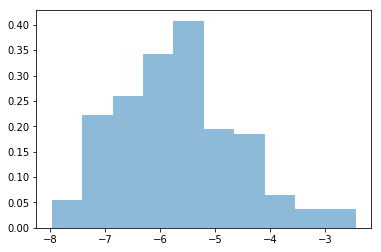

In [12]:

plt.hist(park_df['spread1'], normed=True, alpha=0.5)

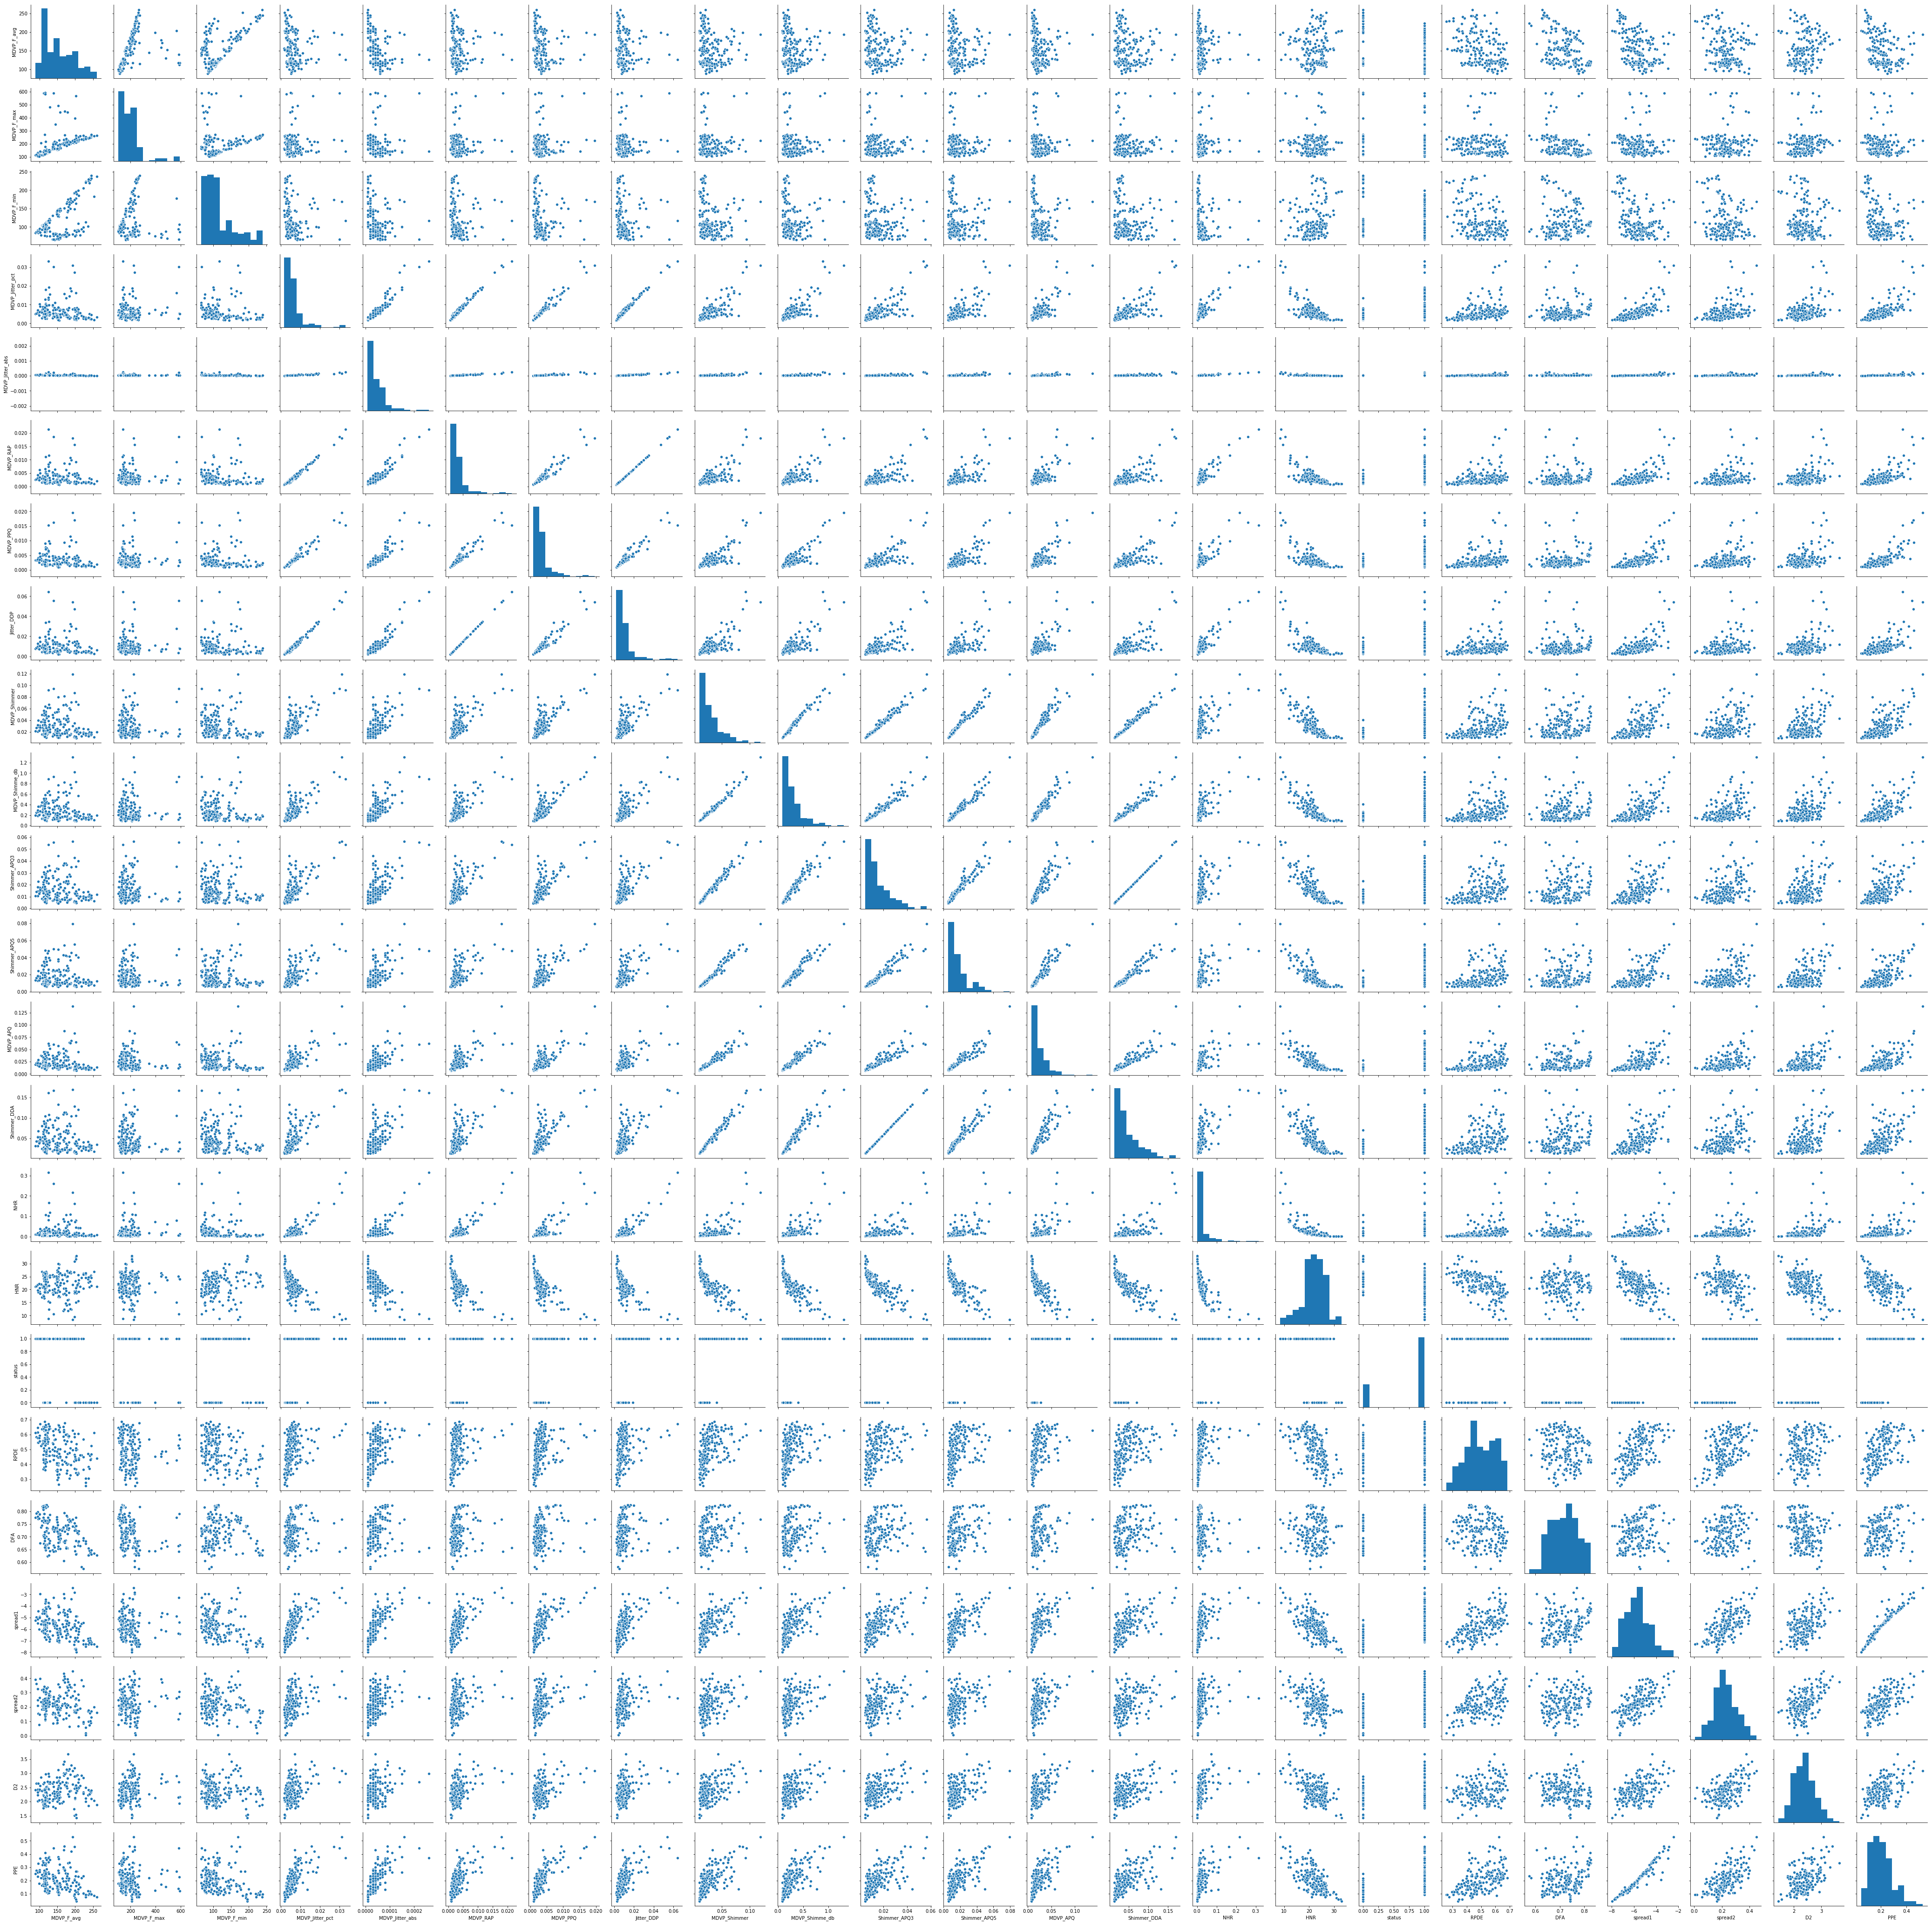

In [13]:
sns.pairplot(park_df)

<Figure size 1440x1440 with 0 Axes>

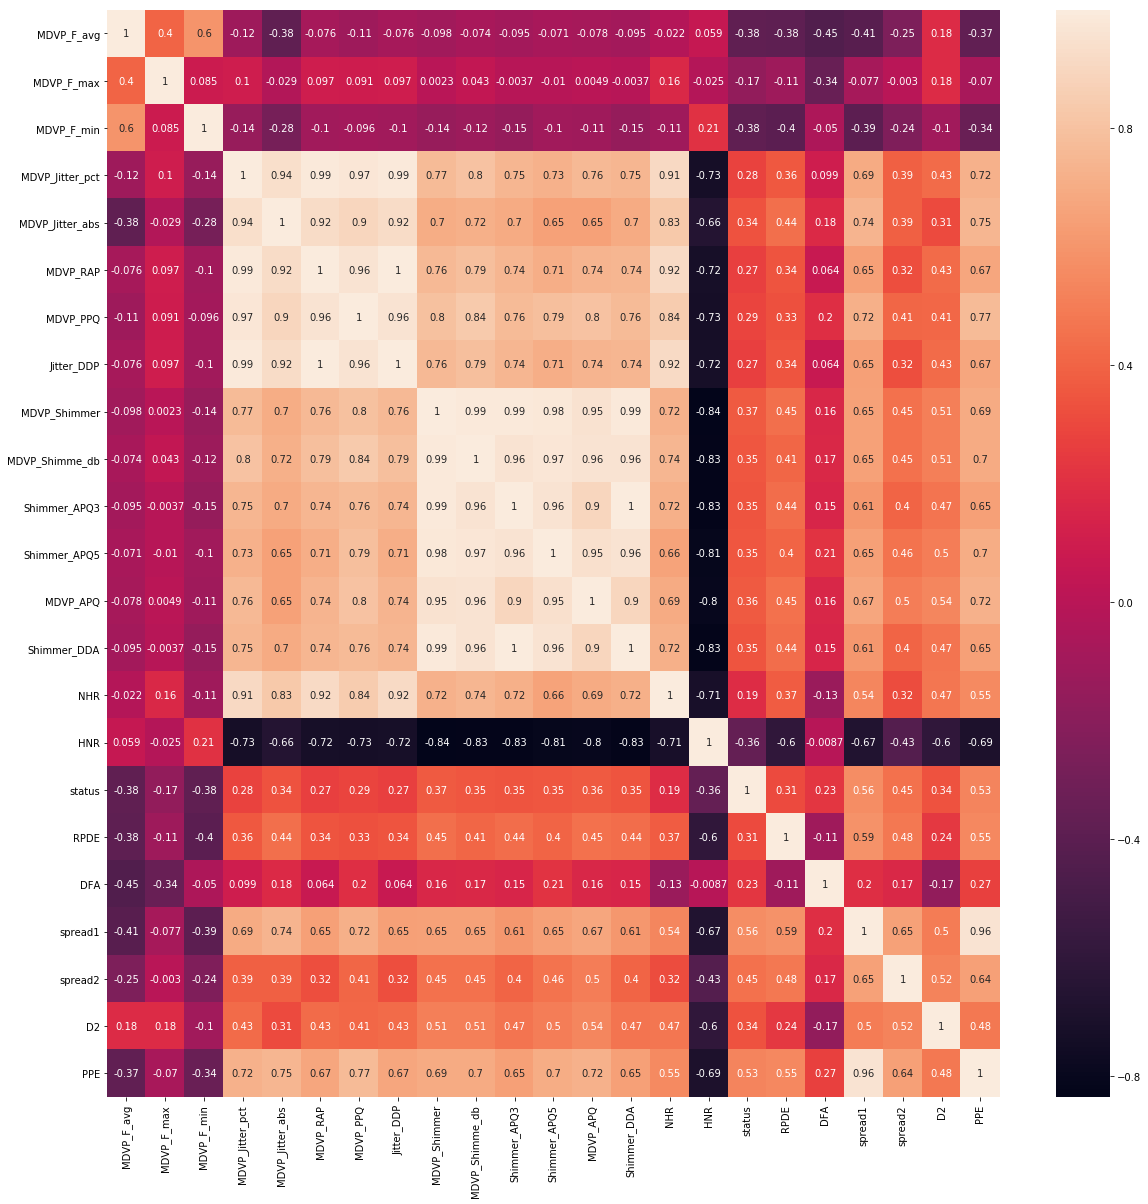

In [14]:
corr = park_df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True)



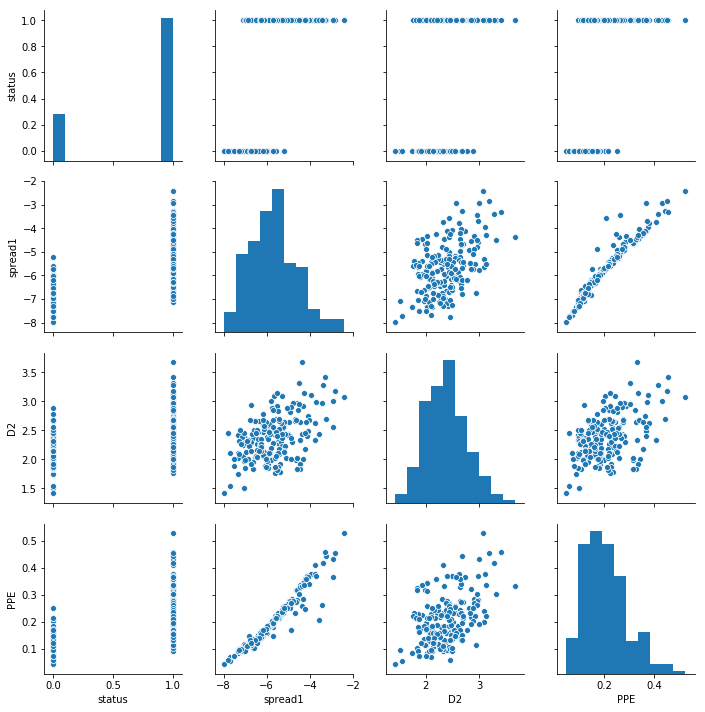

In [15]:
sns.pairplot(park_df[['status','spread1','D2','PPE']])

In [16]:
X = park_df.drop("status", axis=1)
y = park_df["status"]

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [17]:
Xtrain=np.array(X_train)
Ytrain=np.array(y_train)

Xtest=np.array(X_test)
Ytest=np.array(y_test)

In [18]:
model1=DecisionTreeClassifier(random_state=0)
model1.fit(Xtrain,Ytrain)

#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,10),'criterion' : ['entropy','gini']}
GS=GridSearchCV(model1,parameter,cv=3)
GS.fit(X,y)
GS.score(Xtrain,Ytrain)
GS.best_params_

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

0.9852941176470589

{'criterion': 'entropy', 'max_depth': 5}

### Using Gridsreach fitting best model parameters

#### Test data F 1 score best for  max depth =3

In [19]:
model1=DecisionTreeClassifier(max_depth=3,criterion='entropy',random_state=0)
model1.fit(Xtrain,Ytrain)
model1.score(Xtrain,Ytrain)


ypred_dt=model1.predict(Xtest)

print("********* Confusion Matrix **********")
metrics.confusion_matrix(Ytest,ypred_dt)

print("Accuracy score of Test data ",model1.score(Xtest,Ytest) )

pd.DataFrame(data=[accuracy_score(Ytest, ypred_dt),recall_score(Ytest, ypred_dt),
                            precision_score(Ytest, ypred_dt),
                            f1_score(Ytest, ypred_dt)],
                      index=["accuracy", "recall", "precision", "f1_score"])

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=3,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

0.9338235294117647

********* Confusion Matrix **********


array([[11,  1],
       [ 5, 42]])

Accuracy score of Test data  0.8983050847457628


,0
accuracy,0.898305
recall,0.893617
precision,0.976744
f1_score,0.933333


In [20]:
model1=DecisionTreeClassifier(random_state=0)
model1.fit(Xtrain,Ytrain)

#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(3,10),'criterion' : ['entropy','gini'],'min_samples_leaf':np.arange(4,20)}
GS=GridSearchCV(model1,parameter,cv=3)
GS.fit(Xtrain,Ytrain)
GS.score(Xtrain,Ytrain)
GS.best_params_


DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini'], 'min_samples_leaf': array([ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

0.875

{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 15}

#### Regularization of parameters
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 15}

In [21]:
model1=DecisionTreeClassifier(max_depth=3,criterion='entropy',random_state=0,min_samples_leaf=15)
model1.fit(Xtrain,Ytrain)
model1.score(Xtrain,Ytrain)


ypred_dt=model1.predict(Xtest)

print("********* Confusion Matrix **********")
metrics.confusion_matrix(Ytest,ypred_dt)

print("Accuracy score of Test data ",model1.score(Xtest,Ytest) )

pd.DataFrame(data=[accuracy_score(Ytest, ypred_dt),recall_score(Ytest, ypred_dt),
                            precision_score(Ytest, ypred_dt),
                            f1_score(Ytest, ypred_dt)],
                      index=["accuracy", "recall", "precision", "f1_score"])

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=3,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=15, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

0.875

********* Confusion Matrix **********


array([[ 9,  3],
       [ 6, 41]])

Accuracy score of Test data  0.847457627118644


,0
accuracy,0.847458
recall,0.872340
precision,0.931818
f1_score,0.901099


In [22]:
from IPython.display import Image  
from sklearn import tree
from os import system

parkinson_tree_file = open('parkinson_tree.dot','w')
dot_data = tree.export_graphviz(model1, out_file=parkinson_tree_file,
                                feature_names = list(X_train), class_names = ['0','1'])

parkinson_tree_file.close()


# importance of features in the tree building ( The importance of a feature is computed as the 
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )



###### following descion can be viewed on http://www.webgraphviz.com

### Using Regularizartion :
### F1, accuracy, recall & precision have gone down
### Although scores have reduced, we can prevent the model from over fitting 

### Random Forest 

In [24]:
Rf_model = RandomForestClassifier(random_state=0)
parameter={'n_estimators':np.arange(1,60),'criterion' : ['entropy','gini']}
GS=GridSearchCV(Rf_model,parameter,cv=3)
GS.fit(Xtrain,Ytrain)
GS.score(Xtrain,Ytrain)
GS.best_params_

/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

1.0

{'criterion': 'entropy', 'n_estimators': 50}

In [25]:
Rf_model = RandomForestClassifier(random_state=0,n_estimators=50)

Rf_model.fit(Xtrain,Ytrain)
Rf_model.score(Xtrain,Ytrain)


ypred_dt=Rf_model.predict(Xtest)

print("********* Confusion Matrix **********")
metrics.confusion_matrix(Ytest,ypred_dt)

print("Accuracy score of Test data ",Rf_model.score(Xtest,Ytest) )

pd.DataFrame(data=[accuracy_score(Ytest, ypred_dt),recall_score(Ytest, ypred_dt),
                            precision_score(Ytest, ypred_dt),
                            f1_score(Ytest, ypred_dt)],
                      index=["accuracy", "recall", "precision", "f1_score"]).T

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=50, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

1.0

********* Confusion Matrix **********


array([[ 8,  4],
       [ 2, 45]])

Accuracy score of Test data  0.8983050847457628


,accuracy,recall,precision,f1_score
0,0.898305,0.957447,0.918367,0.9375


#### Best number of descision trees as per grid search : 50